# American Options Pricing

As opposed to European options, American options can be exercised at any time until expiry. This complicates calculating their price, and in general requires numerical methods instead of a straightforward analytical solution (an exception being American calls on non-dividend-paying stocks, which are never optimally exercised early and can be priced using Black-Scholes). In this notebook, we explore various numerical methods to achieve this, starting with a binomial model and backwards recursion, then with the Crank-Nicolson method, then with the Longstaff-Schwartz Monte Carlo method. In each, we're pricing an at-the-money American option (S0 = K = 100) with standard parameters (r=5%, σ=20%, T=1yr). 

In [1]:
cd -q ../

In [2]:
from src.pricers.american_options import american_opt_pricer_binomial, american_opt_pricer_CN, plot_payoff_and_value, plot_early_exercise_boundary
from src.pricers.american_options_simulator import american_opt_pricer_MC

## Binomial model

The binomial model uses the binomial distribution, where volatility is incorporated to model price movements at each time step. It takes advantage of the fact that American options can be exercised at any time, allowing decisions to be made by comparing the calculated spot price with the strike price. Backward recursion is then used to determine the option price at time t=0.

The binomial model is generally one of the more intuitive and easier to implement methods, particularly for American options, because early exercise is handled naturally at each node by comparing the continuation value with the exercise payoff. It is also flexible and works well for a wide range of payoff structures. However, achieving high accuracy requires a large number of time steps, which can make it computationally expensive and relatively slow.

### Call options pricing

In [3]:
american_opt_pricer_binomial(
    N=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="call"
)

10.430611662249142

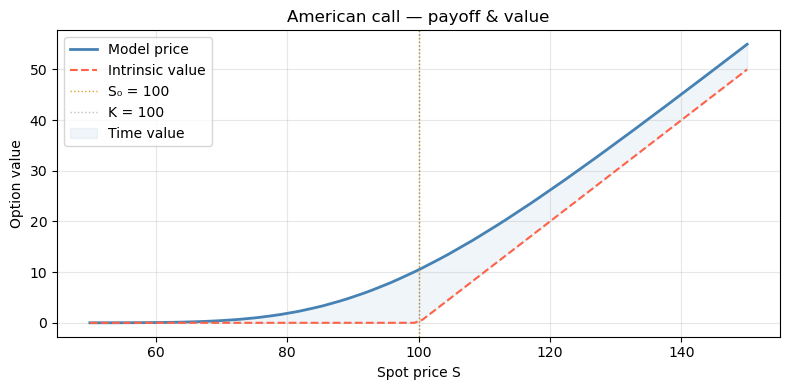

In [4]:
plot_payoff_and_value(
    N=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="call",
    S_range=(0.5, 1.5)
)

### Put options pricing

In [5]:
american_opt_pricer_binomial(
    N=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="put"
)

6.08235440914248

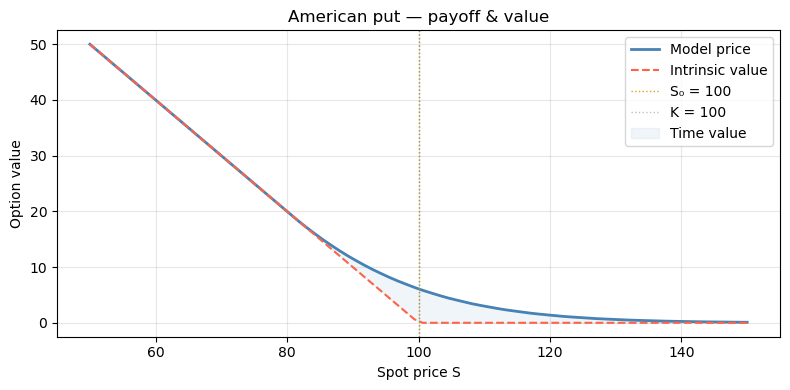

In [6]:
plot_payoff_and_value(
    N=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="put",
    S_range=(0.5, 1.5)
)

## Crank-Nicolson method

The Crank–Nicolson method uses finite difference techniques to solve the Black–Scholes equation numerically. Here, it is applied to price an American option by solving backward in time and, at each step, comparing the option’s continuation value with its immediate exercise value (i.e., the payoff based on the current spot price and the strike price), similar to the binomial model.

The Crank–Nicolson method is typically more accurate and computationally efficient for a given level of precision, as it uses a finite difference scheme with better stability and convergence properties.

### Call options pricing

In [7]:
american_opt_pricer_CN(
    N=150,
    M=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="call"
)

10.44659792209319

### Put options pricing

In [8]:
american_opt_pricer_CN(
    N=150,
    M=100,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="put"
)

6.080336476204678

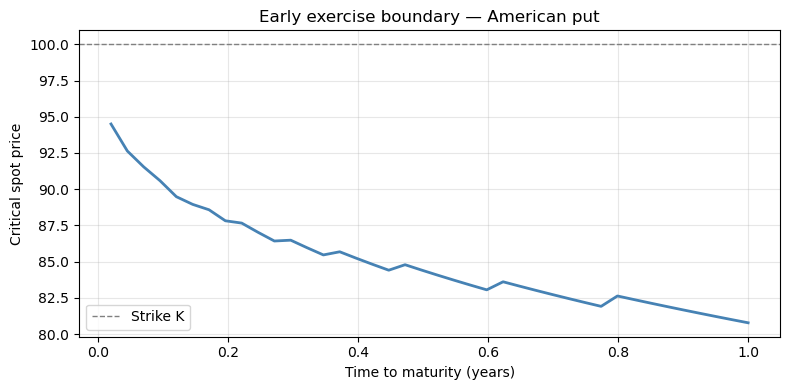

In [9]:
plot_early_exercise_boundary(
    N=150,
    M=100,
    K=100,
    r=0.05,
    sigma=0.2,
    option_type="put"
)

## Longstaff-Schwartz Monte Carlo Method

We explore a stochastic method for pricing an American option, producing a point estimate and a CI. This method starts off similarly to the monte carlo method used to price  European options, but as American options can be exercised before expiry, we work backwards in time, at each step comparing the immediate exercise payoff against the estimated continuation value via least-squares regression, and exercise early where it is optimal to do so.

In [10]:
price, CI = american_opt_pricer_MC(
    N=1000,
    M=1000,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="call"
)

round(price, 3), [round(x, 3) for x in CI]

(10.008, [9.194, 10.822])

In [11]:
price, CI = american_opt_pricer_MC(
    N=1000,
    M=1000,
    S0=100,
    K=100,
    r=0.05,
    sigma=0.2,
    T=1.0,
    option_type="put"
)

round(price, 3), [round(x, 3) for x in CI]

(6.088, [5.681, 6.496])

## Conclusions

For the call option, both the deterministic results (binomial and CN prices) are very closely aligned. Their convergence suggests that the results are comfortably near the true price. The MC estimate is slightly lower but its 95% CI of [9.19, 10.82] contains the other two. 

Note that by the early exercise theorem, an American call on a non-dividend-paying stock should never be exercised early, meaning it prices identically to its European counterpart (~10.45, see notebook 00_european_call_options_pricing.ipynb).

For the put option, which is more interesting for an American option, all three methods produce closely aligned results. Where the European put option was priced at ~5.57 (see notebook 01_european_put_options_pricing.ipynb), an American put option is priced at approximately 6.08. This ~0.51 premium represents the early exercise value from being able to optimally exercise before expiry when deep enough in the money.